# SWIGGY SALES ANALYSIS 

## Importing libraries 

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  #to create interactive charts, dashboards and professional visuals  

## Importing data

In [69]:
df = pd.read_excel('swiggy_data.xlsx')

In [70]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [71]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None
np.set_printoptions(suppress = True)

## Identifing Meta Data

In [72]:
df.shape

(197430, 10)

In [73]:
df.shape[0] #to get rows 

197430

In [74]:
df.shape[1] #to get columns

10

In [75]:
df.dtypes

State                         str
City                          str
Order Date         datetime64[us]
Restaurant Name               str
Location                      str
Category                      str
Dish Name                     str
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  str           
 1   City             197430 non-null  str           
 2   Order Date       197430 non-null  datetime64[us]
 3   Restaurant Name  197430 non-null  str           
 4   Location         197430 non-null  str           
 5   Category         197430 non-null  str           
 6   Dish Name        197430 non-null  str           
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 30.8 MB


In [77]:
#transforming the column names to snake casing for ease of coding and avoiding of errors

In [78]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [79]:
df.columns

Index(['state', 'city', 'order_date', 'restaurant_name', 'location',
       'category', 'dish_name', 'price_(inr)', 'rating', 'rating_count'],
      dtype='str')

In [80]:
df.isnull().sum()

state              0
city               0
order_date         0
restaurant_name    0
location           0
category           0
dish_name          0
price_(inr)        0
rating             0
rating_count       0
dtype: int64

In [81]:
(df['rating'] == 0).any()

np.False_

In [82]:
(df['price_(inr)'] == 0).any()

np.False_

In [83]:
(df['rating_count'] == 0).any()

np.True_

In [84]:
(df['rating_count']== 0).sum()

np.int64(79094)

# imputing weighted ratings

In [85]:
#wr = (v/(v + m) * r + (m/v +m)* c

In [86]:
df.columns

Index(['state', 'city', 'order_date', 'restaurant_name', 'location',
       'category', 'dish_name', 'price_(inr)', 'rating', 'rating_count'],
      dtype='str')

In [87]:
c = df['rating'].mean()
m = df['rating_count'].quantile(0.75)

df['weighted_ratings'] = (
    (df['rating_count']/(df['rating_count'] + m)) * df['rating'] + (m/(df['rating_count'] + m)) * c
)

In [88]:
df['rating_count_issues'] = (df['rating'] > 0) & (df['rating_count'] == 0)

In [89]:
df = df.drop('rating_count_issues', axis = 1)

In [90]:
df.head()

,state,city,order_date,restaurant_name,location,category,dish_name,price_(inr),rating,rating_count,weighted_ratings
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,4.341582
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,4.440593
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,4.614662
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,4.551547
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,4.341582


In [92]:
#finding out how many categories of food items are present in the data  

In [93]:
counts= df['category'].value_counts()

In [94]:
df.describe()

,order_date,price_(inr),rating,rating_count,weighted_ratings
count,197430,197430.000000,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805,4.338174
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000,2.123082
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000,4.328351
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000,4.341582
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000,4.383749
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000,4.981912
std,NaN,219.338363,0.422585,87.542593,0.176828


In [95]:
#df['Rating'] = df['Rating].astype(int) - to change datatype. Float is used for numbers having decimal 

# checking data type

In [96]:
df.dtypes

state                          str
city                           str
order_date          datetime64[us]
restaurant_name                str
location                       str
category                       str
dish_name                      str
price_(inr)                float64
rating                     float64
rating_count                 int64
weighted_ratings           float64
dtype: object

# Checking for outliers

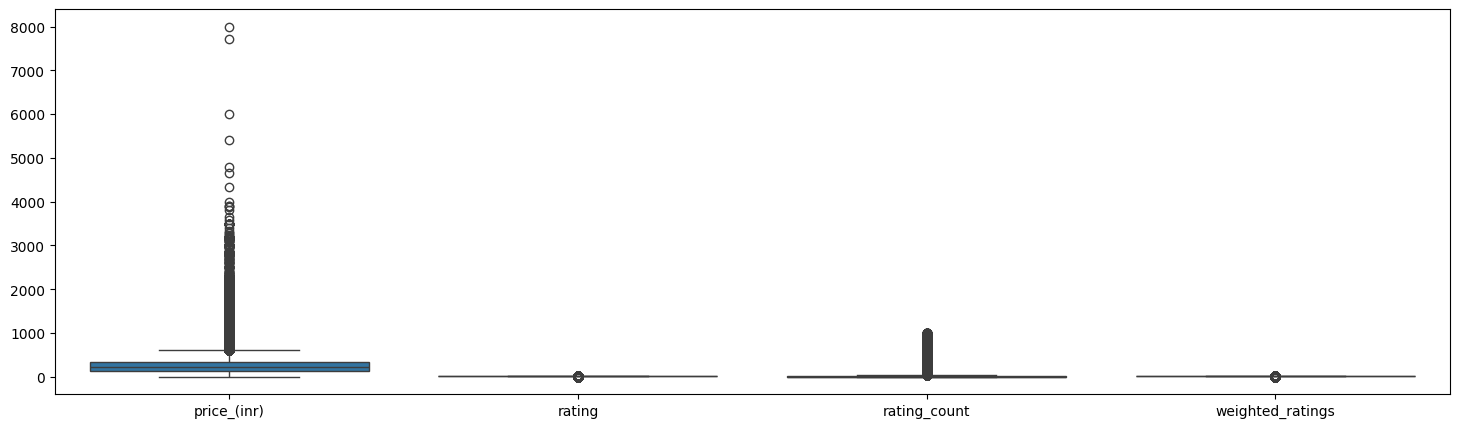

In [97]:
plt.figure(figsize = (18,5))
sns.boxplot(data = df)
plt.show()

In [98]:
Q1 = df['price_(inr)'].quantile(0.25)
Q3 = df['price_(inr)'].quantile(0.75)
IQR = Q3 - Q1

In [99]:
IQR

np.float64(190.0)

In [100]:
outliers = (df['price_(inr)'] < (Q1 - 1.5 * IQR)) | (df['price_(inr)'] > (Q3 + 1.5 * IQR))

In [101]:
outliers.sum()

np.int64(9876)

In [102]:
df['price_(inr)'].describe()

count    197430.000000
mean        268.512920
std         219.338363
min           0.950000
25%         139.000000
50%         229.000000
75%         329.000000
max        8000.000000
Name: price_(inr), dtype: float64

In [103]:
df['city'].value_counts()

city
Bengaluru      20077
Mumbai         10507
Hyderabad      10309
Jaipur         10286
Lucknow        10192
New Delhi      10191
Ahmedabad      10185
Chandigarh     10065
Kolkata        10046
Chennai        10042
Indore          7476
Shillong        5183
Ranchi          5101
Dehradun        5084
Shimla          5054
Guwahati        5032
Panaji          5030
Kochi           5029
Raipur          5025
Bhubaneswar     5018
Agartala        5006
Gurgaon         5005
Imphal          5003
Srinagar        5002
Patna           5000
Aizawl          3091
Kohima          2286
Gangtok         2105
Name: count, dtype: int64

In [104]:
sum_cities = df['city'].value_counts().head(10).sum()

In [105]:
per = sum_cities/197340 * 100
print(per)

56.704165399817576


In [106]:
# Count of orders above 4k and orders less than 20 rs

In [107]:
count_above_4k = (df['price_(inr)'] > 4000).sum()
count_above_20rs = (df['price_(inr)'] < 20).sum()
print("Points above 4k:", count_above_4k)
print("Points below 20:", count_above_20rs)

Points above 4k: 7
Points below 20: 973


In [108]:
outliers = (df['price_(inr)'] > 4000) | (df['price_(inr)'] < 20)

In [109]:
df = df[~outliers]  #can't use df = df[~outliers.any(axis =1)] because we are doing a row level and price column particular removal of outliers. This code will only work on all dataframes

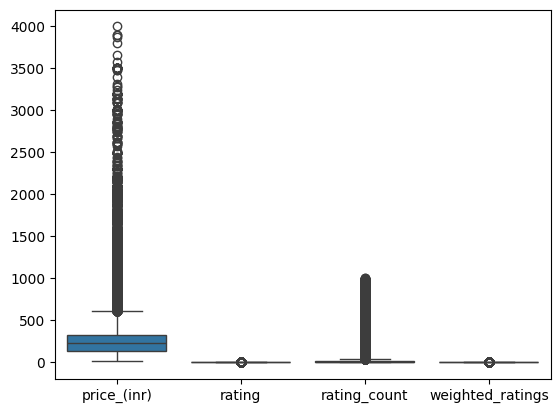

In [110]:
sns.boxplot(data = df)
plt.show()

# Data Period

In [111]:
year_range = df['order_date'].dt.year.agg(['min', 'max'])
print(year_range)

min    2025
max    2025
Name: order_date, dtype: int64


In [112]:
month_range = df['order_date'].dt.month.agg(['min', 'max'])
print(month_range)

min    1
max    8
Name: order_date, dtype: int64


# KPIs

In [113]:
total_sales = df['price_(inr)'].sum().round(2)

In [114]:
print('Total sales for Jan 2025 - to Aug 2025:', total_sales,"₹")

Total sales for Jan 2025 - to Aug 2025: 52959329.57 ₹


In [115]:
#alternate for round: print('total_sales' : round(total_sales,2))

In [116]:
avg_rating = df['weighted_ratings'].mean().round(1)
print('Avg customer rating for Jan 2025 - to Aug 2025 Across All Restaurants:', avg_rating)

Avg customer rating for Jan 2025 - to Aug 2025 Across All Restaurants: 4.3


In [117]:
avg_order_value = df['price_(inr)'].mean().round(2)
print("Average order value for Jan 2025 - to Aug 2025:", avg_order_value, "INR")

Average order value for Jan 2025 - to Aug 2025: 269.58 INR


In [118]:
## Converting suspicious zeros to NaN and then skipping Nan values in calculation of total ratings to avoid misleading data
df['rating_count'] = df['rating_count'].replace(0, pd.NA)

In [119]:
total_reviews = df['rating_count'].sum(skipna = True)
print('Total customer reviews:', total_reviews)

Total customer reviews: 5518486


# Total orders placed

In [120]:
#we should use columns which don't have null values

In [121]:
(df['order_date'] == 0).any()

np.False_

In [122]:
total_orders = df['order_date'].count()
print("Total orders for Jan 2025 - to Aug 2025:", total_orders)  #come back to this

Total orders for Jan 2025 - to Aug 2025: 196450


In [123]:
df.columns

Index(['state', 'city', 'order_date', 'restaurant_name', 'location',
       'category', 'dish_name', 'price_(inr)', 'rating', 'rating_count',
       'weighted_ratings'],
      dtype='str')

# Data Visualization

# 1. Monthly sales trend

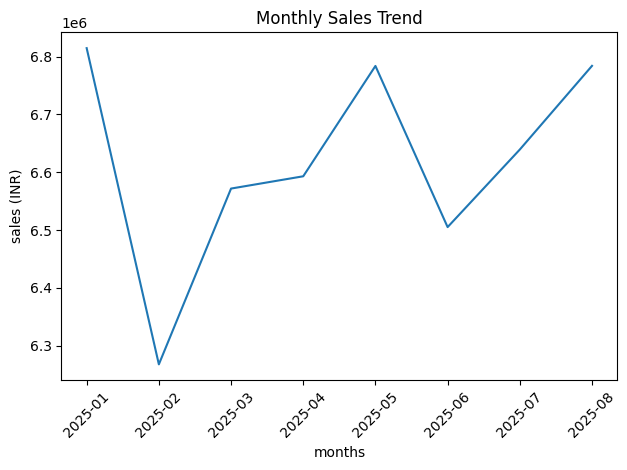

In [124]:
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('year_month')['price_(inr)'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales['year_month'], monthly_sales['price_(inr)'])  #here monhtly_sales is a new dataframe 
plt.xticks(rotation = 45)
plt.xlabel('months')
plt.ylabel('sales (INR)')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

# 2. Daily Sales Trend

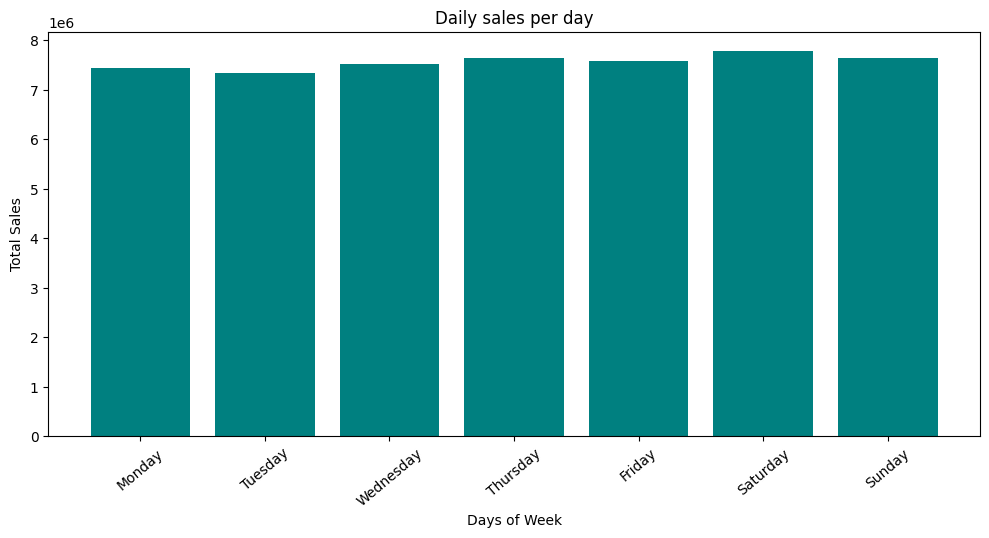

In [125]:
df['days'] = df['order_date'].dt.day_name()
daily_sales = df.groupby('days')['price_(inr)'].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

#bar chat to compare sales trend day wise

plt.figure(figsize = (10,5))
plt.bar(daily_sales.index, daily_sales.values, color = 'teal', label = 'sales')
plt.xlabel("Days of Week")
plt.ylabel("Total Sales")
plt.title("Daily sales per day")
plt.tight_layout()
plt.xticks(rotation = 40)
plt.show()

# 3. Total food sales by food type (no veg, veg)

In [126]:
import re
non_veg =['chicken', 'mutton', 'fish', 'prawns', 'lamb', 'shrimp', 'non veg',  'non-veg', 'kebab', 'kabab', 'egg', 'pork', 'beef',]
pattern = r'\b(' + '|'.join(non_veg) + r')\b'
df['food_cat'] = np.where(
    df['dish_name'].str.lower().str.contains(pattern, na= False),
    'non_veg',
    'veg'
)

C:\Users\samre\AppData\Local\Temp\ipykernel_1304\1498954075.py:5: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



In [127]:
food_revenue = df.groupby('food_cat')['price_(inr)'].sum().reset_index()  #we're creating a new database

In [128]:
fig = px.pie(
    food_revenue, 
    values = "price_(inr)", names = "food_cat", hole = 0.5, title = "Revenue per category: veg vs non veg")

fig.update_traces(textinfo = "percent+label",pull = [0.05,0])

fig.update_layout(
    height = 500,
    margin = dict(t = 60, b = 40, l = 40, r = 40)
)

fig.show()

# Total Sales by State (Map Visualization)

In [129]:
fig = px.bar(
    df.groupby('state', as_index = False)['price_(inr)'].sum().sort_values('price_(inr)', ascending = False),
    x = 'price_(inr)',
    y = 'state',
    orientation = 'h', #to print the bars horizontally 
    title = 'Revenue by state (INR)'
)

fig.update_layout(height = 600, yaxis = dict(autorange = 'reversed'))  #autorange = reversed is used to print the chart horizontally 
fig.show()

# Quarterly Performance Summary

In [131]:
df['quarter'] = df['order_date'].dt.to_period('Q').astype(str)
quarterly_summary = (
    df.groupby('quarter', as_index = False)
    .agg(total_sales = ('price_(inr)', 'sum'),
         avg_rating = ('rating', 'mean'),
         total_orders = ('order_date', 'count')).sort_values('quarter')
)
quarterly_summary['total_sales'] = quarterly_summary['total_sales'].round(0)
quarterly_summary['avg_rating'] = quarterly_summary['avg_rating'].round(2)

quarterly_summary

,quarter,total_sales,avg_rating,total_orders
0,2025Q1,19654096.0,4.34,72714
1,2025Q2,19881967.0,4.34,73804
2,2025Q3,13423266.0,4.34,49932


# Top 5 Cities by Sales

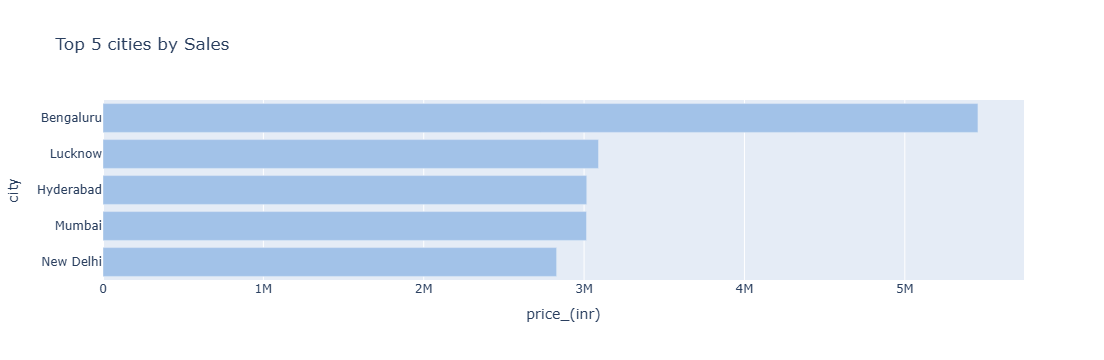

In [140]:
top_5 = (
    df.groupby('city')['price_(inr)'].sum().nlargest(5).sort_values().reset_index())
fig = px.bar(
    top_5, 
    x = 'price_(inr)',
    y = 'city',
    orientation = 'h',
    title = 'Top 5 cities by Sales',
    color_discrete_sequence = ['#a2c2e8']
)

fig.show()

# Weekly Trend Analysis 

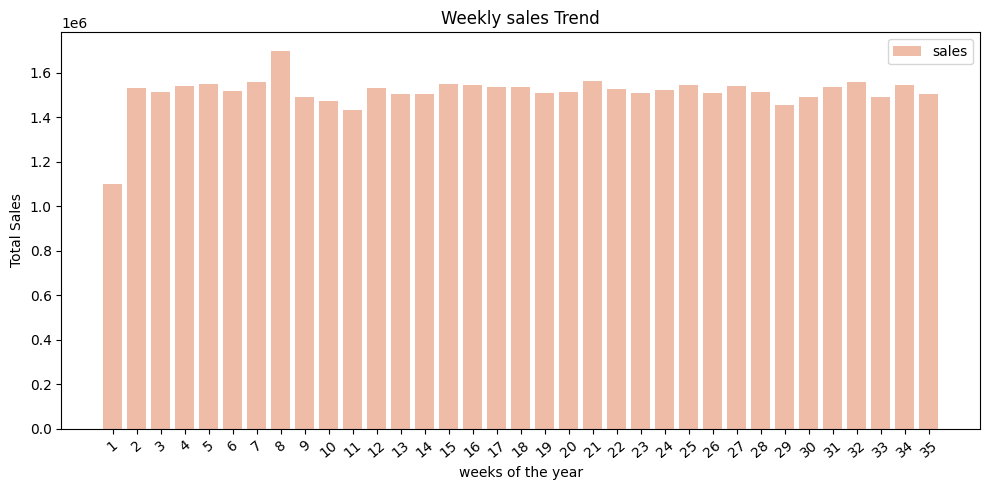

In [139]:
df['week'] = df['order_date'].dt.isocalendar().week
weekly_sales = df.groupby('week')['price_(inr)'].sum().reset_index()

plt.figure(figsize = (10,5))
plt.bar(weekly_sales['week'], weekly_sales['price_(inr)'], color = '#eebca7', label = 'sales')
plt.xlabel("weeks of the year")
plt.ylabel("Total Sales")
plt.title("Weekly sales Trend")
plt.xticks(weekly_sales['week'], rotation = 40)
plt.legend()
plt.tight_layout()
plt.show()